In [1]:
import json
import matplotlib.pyplot as plt

In [2]:
def plot_scores(scores: dict, n_double: int):
    fig, ax = plt.subplots(figsize=(12, 4))
    for concept, vals in scores.items():
        ax.plot(vals, label=concept)
    if n_double:
        ax.axvline(x=n_double, color="gray", linestyle="--", label=f"n_double={n_double}")
    ax.set_xlabel("Token position")
    ax.set_ylabel("Score")
    ax.set_title("Exp1 AV Localization Scores")
    ax.legend()
    plt.tight_layout()
    plt.show()

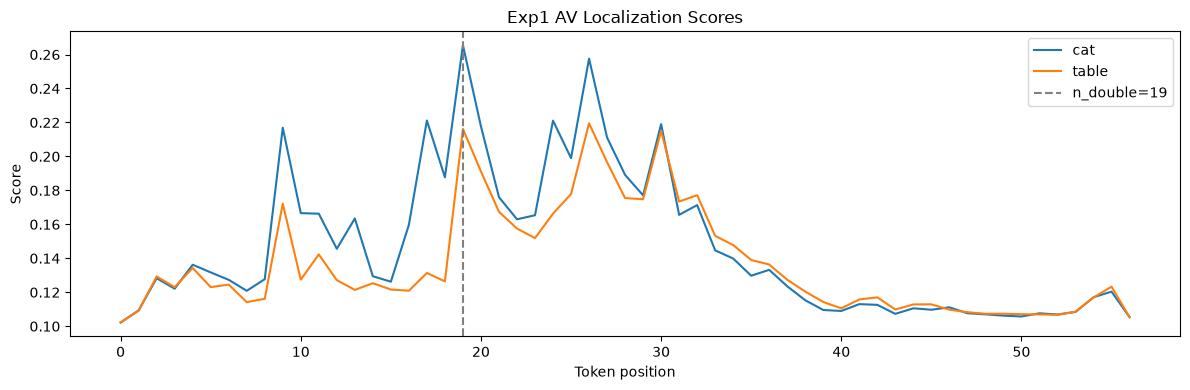

In [3]:
with open("runs/run0/exp1_scores.json") as f:
    data = json.load(f)

plot_scores(data["concepts"], data["n_double"])

In [ ]:
def plot_exp2(metrics: dict):
    layers = metrics["layers"]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(layers, metrics["spread_full"], marker="o", label="spread_full")
    ax.plot(layers, metrics["spread_hi"],   marker="o", label="spread_hi")
    ax.plot(layers, metrics["spread_lo"],   marker="o", label="spread_lo")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Frequency spread")
    ax.set_title(f"Exp2 RoPE Frequency Spread (detail_layer={metrics['detail_layer']})")
    ax.legend()
    plt.tight_layout()
    plt.show()


with open("runs/run0/exp2_metrics.json") as f:
    exp2 = json.load(f)

plot_exp2(exp2)

In [ ]:
def plot_exp3(metrics: dict):
    n = len(metrics["cross_fraction"])
    xs = list(range(n))
    kinds = metrics["kinds"]
    n_double = metrics["n_double"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, key, ylabel in zip(
        axes,
        ["cross_fraction", "ii_entropy", "ii_spread"],
        ["Cross fraction", "II entropy", "II spread"],
    ):
        double_xs = [i for i in xs if kinds[i] == "double"]
        single_xs = [i for i in xs if kinds[i] == "single"]
        ax.scatter(double_xs, [metrics[key][i] for i in double_xs], s=12, label="double")
        ax.scatter(single_xs, [metrics[key][i] for i in single_xs], s=12, label="single")
        ax.axvline(x=n_double, color="gray", linestyle="--", label=f"n_double={n_double}")
        ax.set_xlabel("Token position")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=8)

    fig.suptitle("Exp3 Entanglement Metrics")
    plt.tight_layout()
    plt.show()


with open("runs/run0/exp3_metrics.json") as f:
    exp3 = json.load(f)

plot_exp3(exp3)